<a href="https://colab.research.google.com/github/stakewant/bigdatacomputing/blob/main/numpy_matplotlib_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛠️ 응용문제: Numpy 배열 결합 중심의 전처리 프로그램
- 1) 개별 센서 데이터 통합
- 2) 레이블링
- 3) 훈련 데이터셋 구성의 3단계로 구성

-  핵심 결합 함수
  - np.concatenate((a, b), axis=0):
  - np.vstack((a, b)):
  - np.column_stack((X, y)):
    - 1차원 레이블 배열을 2차원 데이터셋의 새로운 **열(Column)**로 붙인다.
    - 자동으로 y를 2차원으로 해석.
    - np.zeros()
    - np.ones()

In [15]:
# 프로그래밍 문제 : 시계열 데이터 기반 봇 탐지 데이터셋 구축 프로그래밍


## 프로그래밍 문제 : 시계열 데이터 기반 봇 탐지 데이터셋 구축 프로그래밍

- 설명: 웹사이트 접속 로그를 분석하여 자동화된 봇과 실제 사람을 구분하는 기계학습 모델링을 위한 데이터 셋 구축 문제
- 각 사용자로부터 수집한 데이터는 100개의 시점에서 이루어진 수치데이터
- 하기조건에 맞는 데이터 전처리 함수를 작성
- 봇로그와 사람 로그를 비교하는 히스토그램 시각화


In [23]:

#%%writefile numpy_preprocess.py
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.font_manager as fm
import pandas as pd

def setup_korean_font():
    """한글 폰트 설정 (수정 버전)"""
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

    # 1. 폰트 파일 존재 여부 확인 및 설치
    if not os.path.exists(font_path):
        print("Installing Nanum fonts...")
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    # 2. 폰트 매니저에 폰트 추가 (문제의 원인 해결)
    # FontProperties 대신 font_manager.fontManager.addfont를 사용.
    fm.fontManager.addfont(font_path)

    # 3. 전역 설정 적용
    # 'NanumBarunGothic'은 나눔폰트 파일의 실제 이름입니다.
    plt.rc('font', family='NanumBarunGothic')
    plt.rcParams['axes.unicode_minus'] = False
    print("✅ 한글 폰트 설정 완료 (Matplotlib 연동 성공)")

In [17]:
"""
-데이터 수집 :
(1) bot_1(50개), bot_3(30개) 샘플을 각각 생성하고 합치세요 (평균 0, 표준편차 0.001인 정규 분표)
(2) human(80) 샘플을 각각 생성하고 합치세요 (평균 0, 표준편차 0.05 인 정규 분포)
(3) 라벨링: 봇데이터는 1, 사람데이터는 0
(4) 데이터 통합: 모든 샘플 데이터(160개)과 라벨을 2차원 배열로 결합
(5) 데이터 셔플링: 모델 학습 시 편향을 방지하기 위해 데이터 무작위로 섞기

"""

def build_bot_detection_dataset():
  # 1. 데이터 생성
  np.random.seed(42)

  # 시계열 데이터 (봇 데이터)
  bot_1 = np.random.normal(0,0.001, (50,100))
  bot_2 = np.random.normal(0,0.001, (30,100))
  all_bots = np.vstack((bot_1, bot_2))

  # 시계열 데이터 (사람 데이터)
  human = np.random.normal(0, 0.05 ,(80,100))


  # 2. 넘파이 리덕션 집계
  # 모든 데이터 셋을 합치기
  X_data = np.vstack((all_bots, human))

  # 합쳐진 2차원 배열의 통계분포 : 평균, 표준편차
  row_means = np.mean(X_data,axis = 1).reshape(-1,1)
  row_stds = np.std(X_data,axis = 1).reshape(-1,1)


  # 3. 데이터 라벨링
  Y_data = np.concatenate((np.ones(50+30), np.zeros(80))).reshape(-1,1)


  # 4. 최종 결합 : 데이터(100) + 평균(1) + 표준편차(1) + 라벨(1)
  dataset = np.column_stack((X_data, row_means, row_stds, Y_data))


  # 5. 데이터 셔플
  np.random.shuffle(dataset)

  print(dataset.shape)
  print(dataset[:5, 100: ])
  print("데이터셋 구축 완료")

  return dataset

In [18]:
#시각화
def visualize_by_numpy(dataset):
  """
  numpy dataset을 활용한 봇/사람 데이터 분포 시각화
  """

  #표준 편차를 이용한 시각화
  std_vals = dataset[:,-2].astype(float)
  std_values = dataset[:,-1].astype(float)

  #불리언 인덱싱을 사용하여 그룹 이진분류
  bot_std = std_vals[std_values == 1]
  human_std = std_vals[std_values == 0]

  #시각화 설정
  plt.figure(figsize=(10,6))

  #히스토그램 그리기
  plt.hist(bot_std, bins=20, alpha=0.7, label='봇', color='red', edgecolor='black')
  plt.hist(human_std, bins=30, alpha=0.7, label='사람', color='blue', edgecolor='black')

  plt.title('표준 편차 분포 비교')
  plt.xlabel('표준 편차')
  plt.ylabel('사용자 수')
  plt.grid(True)
  plt.legend()
  plt.tight_layout()
  plt.show()

✅ 한글 폰트 설정 완료 (Matplotlib 연동 성공)
(160, 103)
[[-1.34489237e-03  5.53714191e-02  0.00000000e+00]
 [-4.27182279e-03  5.25597692e-02  0.00000000e+00]
 [-3.41912309e-03  4.93708965e-02  0.00000000e+00]
 [-2.20131043e-03  4.72639824e-02  0.00000000e+00]
 [-1.88647790e-04  1.10680960e-03  1.00000000e+00]]
데이터셋 구축 완료


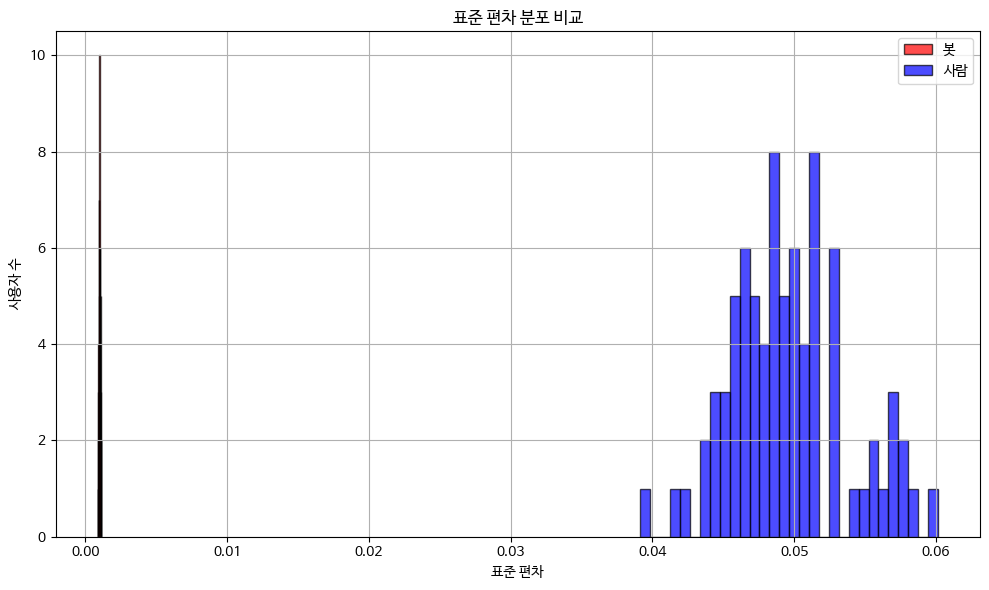

In [24]:
#--- 실행 파트 ---

if __name__ == "__main__":

  # 환경 설정
  setup_korean_font()

  # 데이터 셋 구축 (NumPy 2차원 배열 (160, 103))
  numpy_dataset = build_bot_detection_dataset()

  # 시각화
  visualize_by_numpy(numpy_dataset)